# Building a sample dataset for testing derivative products across different Landsat sensors

This notebook is designed to create a sample set for testing derivative products across the continent, where the testing needs to compare data derived from multiple landsat sensors. It is designed to do the following:

- Import a geojson containing the footprints of the 'golden tiles' that have been previously used for validating GeoMAD products. These tiles are distributed across Australia and across a range of environment types.
- Load a datacube dataset for the selected sensors (in this case, Landsat 7, and Landsat 8/9), using one or more of the golden tiles as the geometry for the datacube query
- Compare the resulting datasets and find the timesteps that overlap ( +/- a timeframe set by the user, e.g. 48 hours)
- If the resulting filtered dataset is very large, create a subset based on randomly selecting smaller regions or pixels
- Export the resulting geojson so it can be used as an input to test workflows

In [1]:
import datacube
import pandas as pd
import numpy as np
import xarray as xr
import geopandas as gpd
import pprint
from datetime import timedelta
import matplotlib.pyplot as plt
from datacube.utils.geometry import CRS, Geometry, GeoBox
from datacube.utils import masking

import sys
sys.path.insert(1, '.../Tools')
from dea_tools.datahandling import load_ard
from dea_tools.dask import create_local_dask_cluster
from dea_tools.plotting import rgb, display_map

In [3]:
create_local_dask_cluster()

/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40651 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/40651/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/40651/status,Workers: 1
Total threads: 15,Total memory: 117.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:46649,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/40651/status,Total threads: 15
Started: Just now,Total memory: 117.21 GiB
Comm: tcp://127.0.0.1:46331,Total threads: 15
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/36915/status,Memory: 117.21 GiB
Nanny: tcp://127.0.0.1:38909,


In [4]:
dc = datacube.Datacube()

In [5]:
def display_polygon(gdf, code):
    code=[code]
    gdf = gdf[gdf['region_code'].isin(code)]
    polygon = gdf.geometry.iloc[0]
    geom = Geometry(geom=polygon, crs=gdf.crs)
    
    bounds = geom.boundingbox
    x_range = (bounds.left, bounds.right)
    y_range = (bounds.bottom, bounds.top)
    
    return x_range, y_range

In [6]:
def select_tile(grid_gdf, region_code, query):
    region_code=[region_code]
    gdf = grid_gdf[grid_gdf['region_code'].isin(region_code)]
    polygon = gdf.geometry.iloc[0]
    
    geom = Geometry(geom=polygon, crs=gdf.crs)
    query.update({'geopolygon': geom})
    
    return query

In [7]:
test_tiles_gdf = gpd.read_file('testing_tile_suite.geojson')

# Extract the list of region_codes
region_codes = test_tiles_gdf['region_code'].tolist()

#remove shortlist once testing is done
region_codes = 'x57y30'
#region_codes = region_codes[1:2]
pprint.pprint(region_codes)

'x57y30'


In [8]:
x_ran, y_ran = display_polygon(test_tiles_gdf, region_codes)
#display_map(x=x_ran, y=y_ran)

### Analysis parameters


In [9]:
time = ('2020-02', '2020-03')
resolution = (-30, 30)
measurements = ["nbart_blue", "nbart_green", "nbart_red"]
#dask_chunks = dict(time=20, x=1024, y=1024)

In [10]:
# set up baseline dc query. THis will be modified by functions as needed later on.
query = {
    'time': time,
    'measurements': measurements,
    'resolution': resolution,
    'output_crs': 'EPSG:3577',
    'group_by': 'solar_day'
}

In [11]:
query = select_tile(test_tiles_gdf, region_codes, query)

print(query)

{'time': ('2020-02', '2020-03'), 'measurements': ['nbart_blue', 'nbart_green', 'nbart_red'], 'resolution': (-30, 30), 'output_crs': 'EPSG:3577', 'group_by': 'solar_day', 'geopolygon': Geometry(POLYGON ((143.68218121959336 -35.589783511618016, 144.73746356701557 -35.507323472556806, 144.84382002673482 -36.36803490788275, 143.77983045581777 -36.45138368333508, 143.68218121959336 -35.589783511618016)), EPSG:4326)}


In [12]:
ds_l8 = load_ard(
    dc=dc,
    products=['ga_ls8c_ard_3'],
    cloud_mask = 'fmask',
    mask_pixel_quality=True,
    mask_contiguity = True,
    dask_chunks = {},
    **query
)

Finding datasets
    ga_ls8c_ard_3
Applying fmask pixel quality/cloud mask
Applying contiguity mask (oa_nbart_contiguity)
Returning 7 time steps as a dask array


In [13]:
ds_l7 = load_ard(
    dc=dc,
    products=['ga_ls7e_ard_3'],
    cloud_mask = 'fmask',
    mask_pixel_quality=True,
    mask_contiguity = True,
    dask_chunks = {},
    **query
)

Finding datasets
    ga_ls7e_ard_3
Applying fmask pixel quality/cloud mask
Applying contiguity mask (oa_nbart_contiguity)
Returning 7 time steps as a dask array


In [14]:
ds_l7

<xarray.Dataset> Size: 860MB
Dimensions:      (time: 7, y: 3201, x: 3200)
Coordinates:
  * time         (time) datetime64[ns] 56B 2020-02-05T23:54:06.724442 ... 202...
  * y            (y) float64 26kB -3.936e+06 -3.936e+06 ... -4.032e+06
  * x            (x) float64 26kB 1.056e+06 1.056e+06 ... 1.152e+06 1.152e+06
    spatial_ref  int32 4B 3577
Data variables:
    nbart_blue   (time, y, x) float32 287MB dask.array<chunksize=(1, 3201, 3200), meta=np.ndarray>
    nbart_green  (time, y, x) float32 287MB dask.array<chunksize=(1, 3201, 3200), meta=np.ndarray>
    nbart_red    (time, y, x) float32 287MB dask.array<chunksize=(1, 3201, 3200), meta=np.ndarray>
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [15]:
# convert nodata from -999 to NaN before passing to the function
ds_l7 = masking.mask_invalid_data(ds_l7)
ds_l8 = masking.mask_invalid_data(ds_l8)

In [16]:
#rgb(ds_l8, bands=['nbart_red', 'nbart_green', 'nbart_blue'], col='time', robust=True, col_wrap=4)

In [17]:
#rgb(ds_l7, bands=['nbart_red', 'nbart_green', 'nbart_blue'], col='time', robust=True, col_wrap=4)

In [18]:
# match L7 and L8 with a 2-day tolerance
ds_l7_filtered = ds_l7.reindex(time=ds_l8.time, method='nearest', tolerance = np.timedelta64(1, 'D'))

In [19]:
ds_l7_aligned, ds_l8_aligned = xr.align(ds_l7_filtered, ds_l8, join='inner')

combined = xr.concat([ds_l7_aligned, ds_l8_aligned], dim='satellite')
combined = combined.assign_coords(satellite=['l7', 'l8'])

valid_mask = combined.notnull().all(dim='satellite')

masked_combined = combined.where(valid_mask)

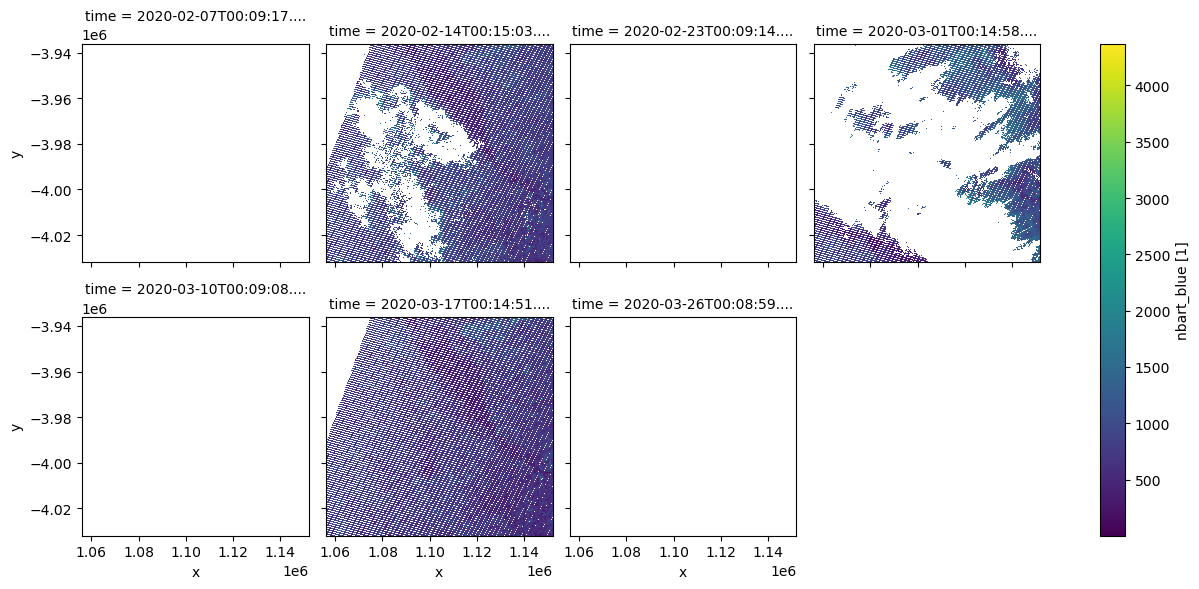

In [20]:
ds_l7_filtered.nbart_blue.plot(col='time', col_wrap=4)

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


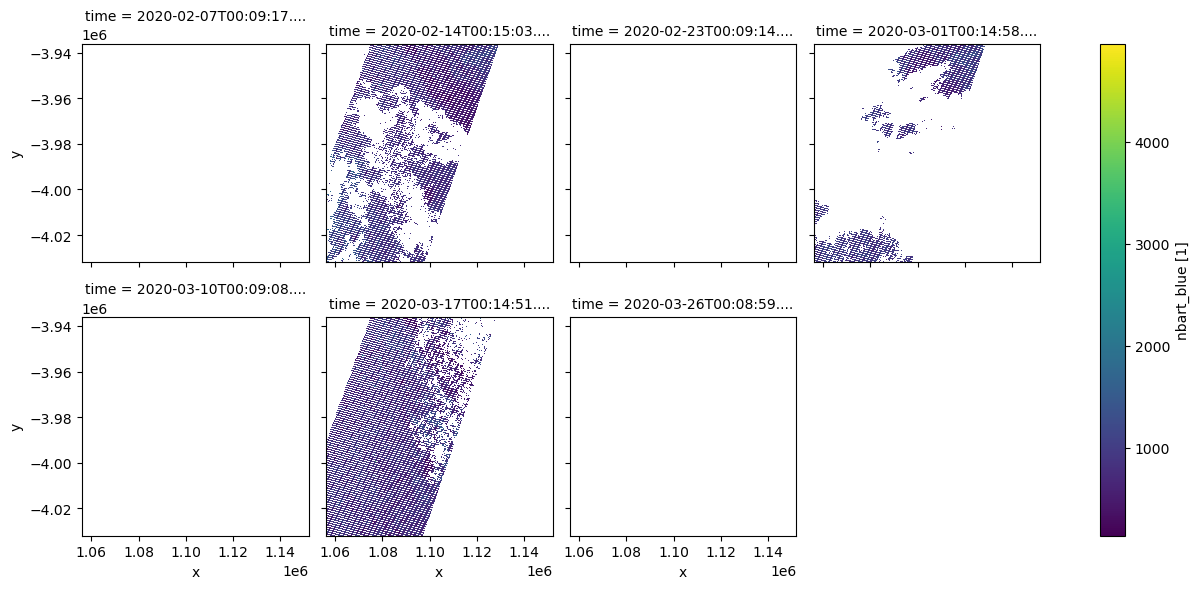

In [21]:
masked_combined.sel(satellite = 'l8')['nbart_blue'].plot(col='time', col_wrap=4)